In [246]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [247]:
df = pd.read_csv("../../../data/processed/M1_dataset.csv")
df_normal_ruo = pd.DataFrame()
df_normal_ruo["ruonia data"] = pd.to_datetime(df["DT"])
df_normal_ruo["ruonia"] = df["ruo"]
df_normal = pd.DataFrame()
df_normal["start data medium"] = pd.to_datetime(df["Период усреднения обязательных резервов"][::-1].values)
df_normal["count days"] = df["Число календарных дней в периоде усреднения обязательных резервов"][::-1].values
df_normal["end data medium"] = df_normal["start data medium"] + pd.to_timedelta(df_normal["count days"], unit="D")
df_normal["Kor CB"] = df["Фактические среднедневные остатки средств на корсчетах"][::-1].values
df_normal["Res norm"] = df["Обязательные резервы, подлежащие усреднению на корсчетах"][::-1].values
df_normal["Res count"] = df["Обязательные резервы на счетах для их учета"][::-1].values
df_normal = df_normal.dropna()
df_normal = df_normal[df_normal["start data medium"] >= "2010-01-11"]

daily = df_normal_ruo.copy()
periods = df_normal.copy()
    
# Убедимся, что даты в правильном формате
daily["ruonia data"] = pd.to_datetime(daily["ruonia data"])
periods["start data medium"] = pd.to_datetime(periods['start data medium'])
periods['end data medium'] = pd.to_datetime(periods['end data medium'])
    
# Сортируем оба датасета по дате и началу периода
daily = daily.sort_values("ruonia data").reset_index(drop=True)
periods = periods.sort_values("start data medium").reset_index(drop=True)
    
    # merge_asof: для каждой даты подбираем последний период, где start_date <= дата
merged = pd.merge_asof(
    daily,
    periods,
    left_on="ruonia data",
    right_on="start data medium",
    direction='backward'  # берём последнюю строку с start_date <= дата
)
    
    # Теперь нужно проверить, что дата <= end_date
    # Определяем колонки, которые пришли из periods (кроме start_date, end_date)
value_cols = [c for c in periods.columns if c not in ('start_date', 'end_date')]
    
    # Формируем маску: дата входит в период
mask = (merged["ruonia data"] >= merged['start data medium']) & (merged["ruonia data"] <= merged['end data medium'])
    
for col in value_cols:
    merged.loc[~mask, col] = np.nan
    
merged = merged.drop(columns=['start data medium', 'end data medium', "count days"])
merged = merged.dropna()
def flag_end_of_period(d, df_month):
    mask = (d >= (df_month["end data medium"] - pd.Timedelta(days=3)))&(d <= df_month["end data medium"])
    return int(mask.any())

merged["flag_end_period"] = merged["ruonia data"].apply(lambda d: flag_end_of_period(d, df_normal))
merged["spread"] = merged["Kor CB"] - merged["Res norm"]

#merged.head(30)


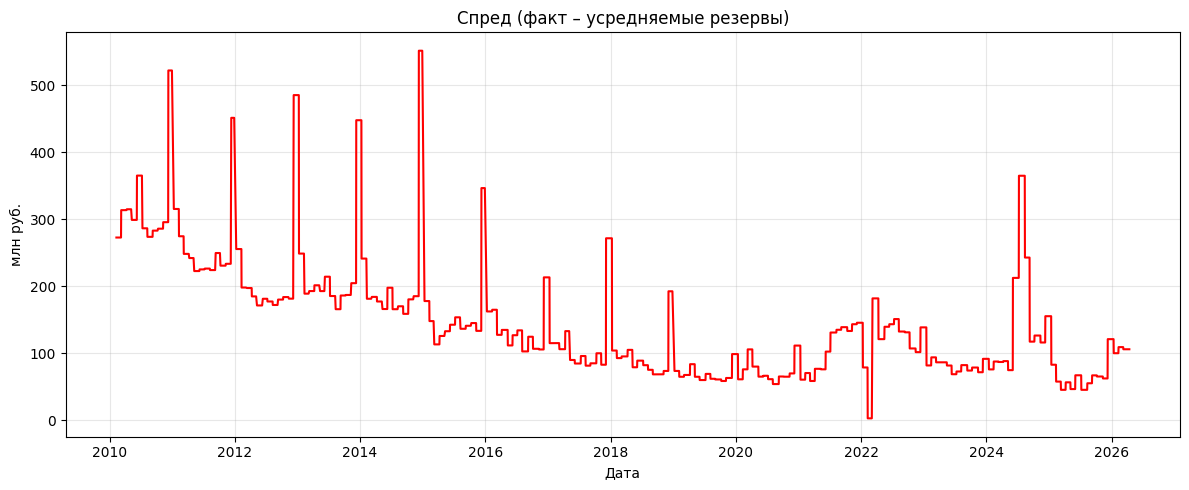

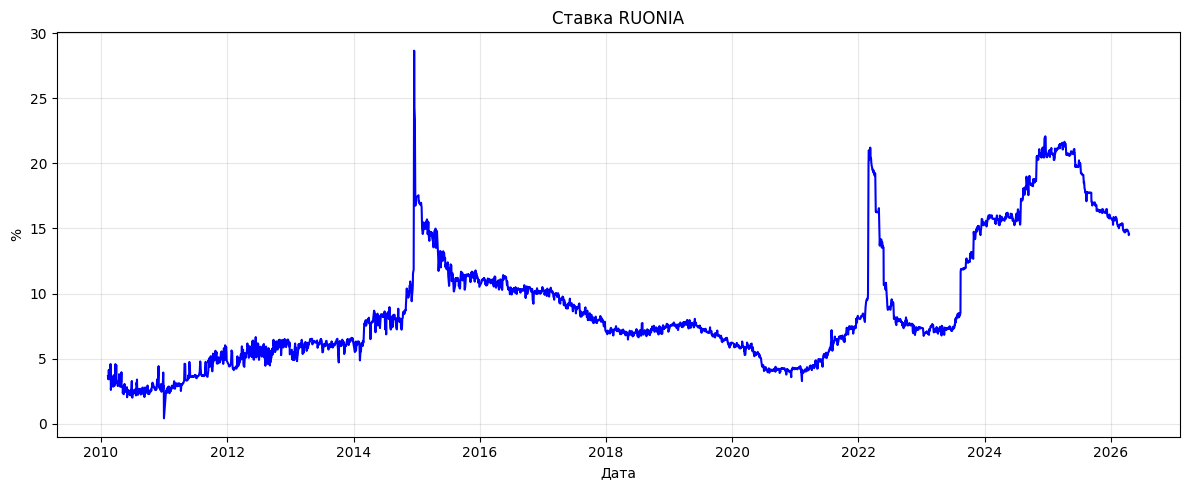

In [248]:
import count_signal
import importlib
importlib.reload(count_signal)
from count_signal import M1CountSignals

signal = M1CountSignals(merged)
signal.mad_score_ruonia()
signal.mad_score_spread()

def graf(merged):
    dates = merged['ruonia data']

    # ── График 1: Спред ──
    plt.figure(figsize=(12, 5))
    plt.plot(dates, merged['spread'],
                color='red', linewidth=1.5)
    plt.title('Спред (факт – усредняемые резервы)')
    plt.xlabel('Дата')
    plt.ylabel('млн руб.')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ── График 2: RUONIA ──
    plt.figure(figsize=(12, 5))
    plt.plot(dates, merged['ruonia'],
                 color='blue', linewidth=1.5)
    plt.title('Ставка RUONIA')
    plt.xlabel('Дата')
    plt.ylabel('%')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

graf(merged)



merged = merged.drop(["Kor CB", "Res norm","Res count"], axis=1)
merged.to_csv("../../../ml-services/modules/m1_reserves/m1_all.csv")



